In [83]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch.nn as nn
import numpy as np

In [84]:
df = pd.read_csv("../Veriler/08-seismic_activity_svm.csv")
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [85]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB
None
       underground_wave_energy  vibration_axis_variation  \
count               400.000000              4.000000e+02   
mean                  0.000000              8.881784e-18   
std                   7.719350              1.751650e+00   
min                  -9.999954             -3.000000e+00   
25%                  -6.134779             -1.500000e+00   
50%                   0.000000              0.000000e+00   
75%                   6.134779              1.500000e+00   
max                   9.999954              3.000000e+00   

       seismic_event_dete

In [86]:
x = torch.tensor(df[['underground_wave_energy','vibration_axis_variation']].values,dtype=torch.float32)
y = torch.tensor(df['seismic_event_detected'].values,dtype=torch.float32).unsqueeze(1)

In [87]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.8, random_state=42)

<function matplotlib.pyplot.show(close=None, block=None)>

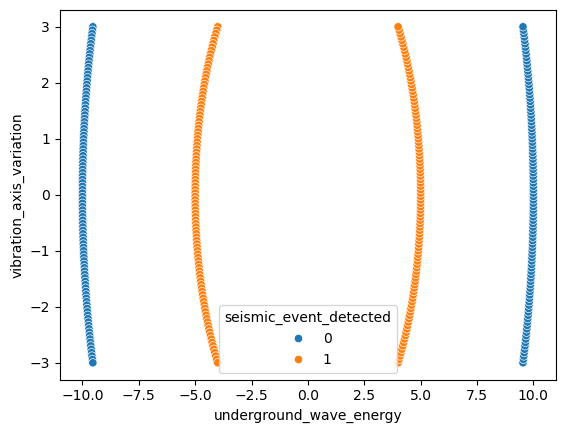

In [88]:
sns.scatterplot(x=df['underground_wave_energy'], y=df['vibration_axis_variation'], hue=df['seismic_event_detected'])
plt.show

In [89]:
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=5,dtype=torch.float32)
        self.relu_1 = nn.GELU()
        self.layer_2 = nn.Linear(in_features=5,out_features=7,dtype=torch.float32)
        self.relu_2 = nn.GELU()
        self.layer_3 = nn.Linear(in_features=7,out_features=1,dtype=torch.float32)
        
    def forward(self,x):
        out = self.layer_1(x)
        out = self.relu_1(out)
        out = self.layer_2(out)
        out = self.relu_2(out)
        out = self.layer_3(out)
        return out

In [90]:
model = SimpleModel()

In [91]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.01)

In [92]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    accuracy = (correct / len(y_pred)) *100
    return accuracy

In [93]:
torch.manual_seed(42)
epochs = 200

epoch_count = []
train_loss_count = []
train_acc_count = []

for epoch in range(epochs):
    model.train()
    y_logits = model(x_train)
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits,y_train)
    acc = calculate_accuracy(y_train,y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(x_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,y_test)
        test_acc  = calculate_accuracy(y_test,test_pred) 

        epoch_count.append(epoch)
        train_loss_count.append(loss.item())
        train_acc_count.append(acc)
        
        if epoch % 10 == 0:
            print(f"Epoch:{epoch}, Loss:{loss}, Acc:{acc}, Test_Loss:{test_loss}, Test_Acc:{test_acc}")

Epoch:0, Loss:0.7034393548965454, Acc:52.81249999999999, Test_Loss:0.6871188282966614, Test_Acc:57.49999999999999
Epoch:10, Loss:0.6055058240890503, Acc:52.1875, Test_Loss:0.5486524701118469, Test_Acc:56.25
Epoch:20, Loss:0.5464945435523987, Acc:55.3125, Test_Loss:0.4998845160007477, Test_Acc:67.5
Epoch:30, Loss:0.4807104468345642, Acc:70.3125, Test_Loss:0.4455464780330658, Test_Acc:82.5
Epoch:40, Loss:0.41082364320755005, Acc:100.0, Test_Loss:0.3872860074043274, Test_Acc:100.0
Epoch:50, Loss:0.3336254954338074, Acc:100.0, Test_Loss:0.3136228621006012, Test_Acc:100.0
Epoch:60, Loss:0.25813186168670654, Acc:100.0, Test_Loss:0.24023135006427765, Test_Acc:100.0
Epoch:70, Loss:0.19193121790885925, Acc:100.0, Test_Loss:0.17779132723808289, Test_Acc:100.0
Epoch:80, Loss:0.13435320556163788, Acc:100.0, Test_Loss:0.12416984140872955, Test_Acc:100.0
Epoch:90, Loss:0.08604738861322403, Acc:100.0, Test_Loss:0.07953327894210815, Test_Acc:100.0
Epoch:100, Loss:0.05239749699831009, Acc:100.0, Test_L

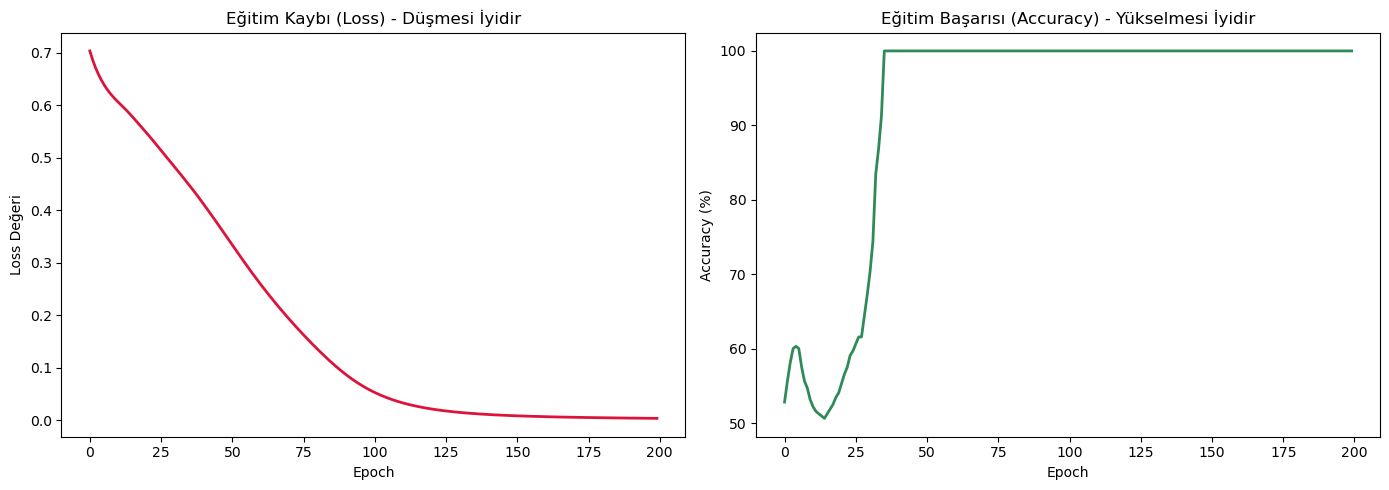

In [94]:
def plot_training_history(epochs_list, loss_list, acc_list):
    """
    Eğitim sürecindeki Kayıp (Loss) ve Başarı (Accuracy) değişimini yan yana çizer.
    """
    # 1 satır, 2 sütunluk (yan yana) bir grafik panosu aç
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Sol taraf (Loss grafiği) - Kırmızı renk
    sns.lineplot(x=epochs_list, y=loss_list, ax=axes[0], color='crimson', linewidth=2)
    axes[0].set_title("Eğitim Kaybı (Loss) - Düşmesi İyidir")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss Değeri")
    
    # Sağ taraf (Accuracy grafiği) - Yeşil renk
    sns.lineplot(x=epochs_list, y=acc_list, ax=axes[1], color='seagreen', linewidth=2)
    axes[1].set_title("Eğitim Başarısı (Accuracy) - Yükselmesi İyidir")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    
    plt.tight_layout()
    plt.show()
plot_training_history(epoch_count, train_loss_count, train_acc_count)

In [95]:
def plot_nonlinear_decision_boundary(model, X, y):

    # Grid alanını tanımla (tüm veri aralığını kapsasın)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Grid'i modele sokmak için tensor'a çevir
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Tahmin al
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary çizimi (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    
    # Gerçek noktalar
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

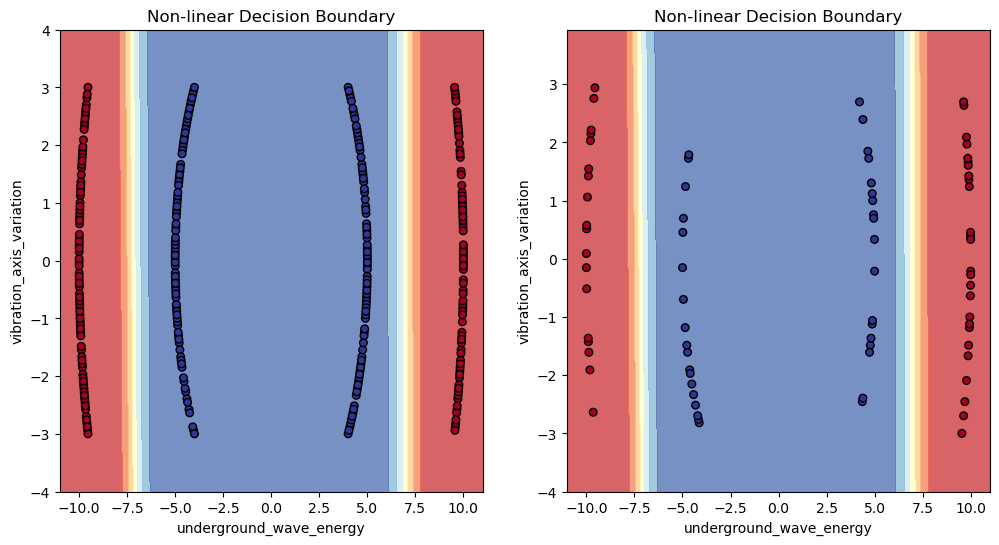

In [96]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model, x_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model, x_test, y_test)

plt.show()